In [1]:
# Import Required Libraries
import os
import numpy as np
import random
import shutil
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, DenseNet121, EfficientNetB0, EfficientNetB3
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Set the dataset directory
DATASET_DIR = "/content/drive/MyDrive/Project Database/Blood Cell Images Classified for Leukemia Type Detection/Dataset"

# List of class names (the leukemia types)
CLASS_NAMES = ["MM", "Healthy", "CML", "CLL", "AML", "ALL"]

# Ensure class folders exist
for c in CLASS_NAMES:
    p = os.path.join(DATASET_DIR, c)
    if not os.path.isdir(p):
        raise FileNotFoundError(f"Missing class folder: {p}")

print("Found class folders:", CLASS_NAMES)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found class folders: ['MM', 'Healthy', 'CML', 'CLL', 'AML', 'ALL']


In [3]:
# Split Dataset into Train, Validation, and Test
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TRAIN_DIR = os.path.join(DATASET_DIR, "Train")
VAL_DIR = os.path.join(DATASET_DIR, "Validation")
TEST_DIR = os.path.join(DATASET_DIR, "Test")

# Check if directories already have images
def dir_has_images(d):
    if not os.path.isdir(d):
        return False
    for root, _, files in os.walk(d):
        for f in files:
            if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp")):
                return True
    return False

# Split dataset only if not already done
def split_dataset_if_needed():
    if dir_has_images(TRAIN_DIR) and dir_has_images(VAL_DIR) and dir_has_images(TEST_DIR):
        print("Train/Validation/Test already exist with images, skipping split.")
        return

    os.makedirs(TRAIN_DIR, exist_ok=True)
    os.makedirs(VAL_DIR, exist_ok=True)
    os.makedirs(TEST_DIR, exist_ok=True)

    # Create class directories and split images
    for c in CLASS_NAMES:
        os.makedirs(os.path.join(TRAIN_DIR, c), exist_ok=True)
        os.makedirs(os.path.join(VAL_DIR, c), exist_ok=True)
        os.makedirs(os.path.join(TEST_DIR, c), exist_ok=True)

        src = os.path.join(DATASET_DIR, c)
        imgs = [f for f in os.listdir(src) if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp"))]
        if len(imgs) == 0:
            raise RuntimeError(f"No images found in {src}")

        random.shuffle(imgs)
        n = len(imgs)
        n_train = int(0.6 * n)
        n_val = int(0.2 * n)

        # Split into train, validation, test
        train_imgs = imgs[:n_train]
        val_imgs = imgs[n_train:n_train+n_val]
        test_imgs = imgs[n_train+n_val:]

        for f in train_imgs:
            shutil.copy2(os.path.join(src, f), os.path.join(TRAIN_DIR, c, f))
        for f in val_imgs:
            shutil.copy2(os.path.join(src, f), os.path.join(VAL_DIR, c, f))
        for f in test_imgs:
            shutil.copy2(os.path.join(src, f), os.path.join(TEST_DIR, c, f))

    print("Split completed: 60/20/20 into Train/Validation/Test.")

split_dataset_if_needed()

Train/Validation/Test already exist with images, skipping split.


In [4]:
# Build tf.data pipelines for efficient data loading
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class order used by datasets:", class_names)
print("Num classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE

# Enable caching and prefetching for faster data loading
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1440 files belonging to 6 classes.
Found 480 files belonging to 6 classes.
Found 480 files belonging to 6 classes.
Class order used by datasets: ['ALL', 'AML', 'CLL', 'CML', 'Healthy', 'MM']
Num classes: 6


In [5]:
# Data Augmentation applied only to training data
data_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10),
], name="augmentation")

In [6]:
# Helper function to build transfer learning model with proper preprocessing and Global Average Pooling
def build_tl_model(base_model, preprocess_fn, model_name):
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = data_augment(inputs)  # augmentation only helps if model sees variety
    x = layers.Lambda(lambda z: preprocess_fn(z))(x)  # correct preprocessing per model
    base_model.trainable = False  # Freeze base model initially
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)  # GAP instead of Flatten for better generalization
    x = layers.Dropout(0.35)(x)  # Dropout for regularization
    outputs = layers.Dense(num_classes, activation="softmax")(x)  # Final classifier
    model = tf.keras.Model(inputs, outputs, name=model_name)
    return model

In [7]:
# Define 3 strong models (VGG16, DenseNet121, EfficientNetB0) using transfer learning
vgg_base = VGG16(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
densenet_base = DenseNet121(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
effnet_base = EfficientNetB3(weights="imagenet", include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))  # EfficientNetB3 for better performance

# Build models
vgg_model = build_tl_model(vgg_base, vgg_preprocess, "VGG16_TL")
densenet_model = build_tl_model(densenet_base, densenet_preprocess, "DenseNet121_TL")
effnet_model = build_tl_model(effnet_base, effnet_preprocess, "EfficientNetB3_TL")

print(vgg_model.name, densenet_model.name, effnet_model.name)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
VGG16_TL DenseNet121_TL EfficientNetB3_TL


In [8]:
# Train the Models in Two Stages: First train head, then fine-tune top layers
def train_two_stage(model, base_model, train_ds, val_ds, out_prefix):
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"{out_prefix}.keras",
            monitor="val_accuracy",
            save_best_only=True
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=6,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-7
        )
    ]

    # Stage 1: Train only the classifier head
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    hist1 = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=callbacks)

    # Stage 2: Fine-tune last layers of base model
    base_model.trainable = True

    # Unfreeze the last ~30% layers
    n_layers = len(base_model.layers)
    fine_tune_at = int(n_layers * 0.70)
    for i, layer in enumerate(base_model.layers):
        layer.trainable = (i >= fine_tune_at)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    hist2 = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

    return hist1, hist2

In [9]:
# Train All 3 Models: VGG16, DenseNet121, EfficientNetB3
hist_vgg_1, hist_vgg_2 = train_two_stage(vgg_model, vgg_base, train_ds, val_ds, "best_vgg16")
hist_dn_1, hist_dn_2 = train_two_stage(densenet_model, densenet_base, train_ds, val_ds, "best_densenet121")
hist_en_1, hist_en_2 = train_two_stage(effnet_model, effnet_base, train_ds, val_ds, "best_effnetb3")

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.2018 - loss: 5.4930 - val_accuracy: 0.4250 - val_loss: 2.1614 - learning_rate: 0.0010
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step - accuracy: 0.3536 - loss: 3.1206 - val_accuracy: 0.5646 - val_loss: 1.4134 - learning_rate: 0.0010
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.4260 - loss: 2.2405 - val_accuracy: 0.6083 - val_loss: 1.1942 - learning_rate: 0.0010
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.4913 - loss: 1.9489 - val_accuracy: 0.6812 - val_loss: 0.9894 - learning_rate: 0.0010
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.5672 - loss: 1.4497 - val_accuracy: 0.7063 - val_loss: 0.9551 - learning_rate: 0.0010
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 180ms/step - accuracy: 0.5669 - loss: 1.4369 - val_accuracy: 0.7146 - val_loss: 0.8994 - learning_rate: 0.0010
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 179ms/step - accuracy: 0.6095 - loss: 1.1884 -

In [10]:
# Evaluate Models: Accuracy, Classification Report, Confusion Matrix
def collect_predictions(model, dataset):
    y_true = []
    y_pred = []
    for x, y in dataset:
        p = model.predict(x, verbose=0)
        y_true.extend(np.argmax(y.numpy(), axis=1))
        y_pred.extend(np.argmax(p, axis=1))
    return np.array(y_true), np.array(y_pred)

def plot_confusion(cm, labels, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

def evaluate_and_report(model, name):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    y_true, y_pred = collect_predictions(model, test_ds)

    print("\nModel:", name)
    print("Test accuracy:", round(float(test_acc), 4))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion(cm, class_names, f"Confusion matrix: {name}")
    return test_acc


Model: VGG16
Test accuracy: 0.9062

Classification report:
              precision    recall  f1-score   support

         ALL     1.0000    1.0000    1.0000        80
         AML     0.8462    0.6875    0.7586        80
         CLL     0.8452    0.8875    0.8659        80
         CML     0.7667    0.8625    0.8118        80
     Healthy     1.0000    1.0000    1.0000        80
          MM     0.9877    1.0000    0.9938        80

    accuracy                         0.9062       480
   macro avg     0.9076    0.9062    0.9050       480
weighted avg     0.9076    0.9062    0.9050       480



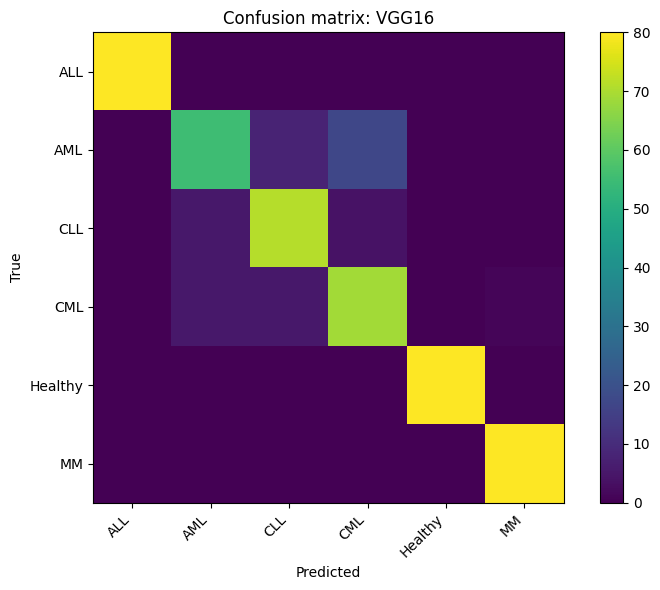


Model: DenseNet121
Test accuracy: 0.8687

Classification report:
              precision    recall  f1-score   support

         ALL     0.9756    1.0000    0.9877        80
         AML     0.8000    0.7000    0.7467        80
         CLL     0.7474    0.8875    0.8114        80
         CML     0.7143    0.6250    0.6667        80
     Healthy     0.9756    1.0000    0.9877        80
          MM     0.9877    1.0000    0.9938        80

    accuracy                         0.8688       480
   macro avg     0.8668    0.8688    0.8656       480
weighted avg     0.8668    0.8688    0.8656       480



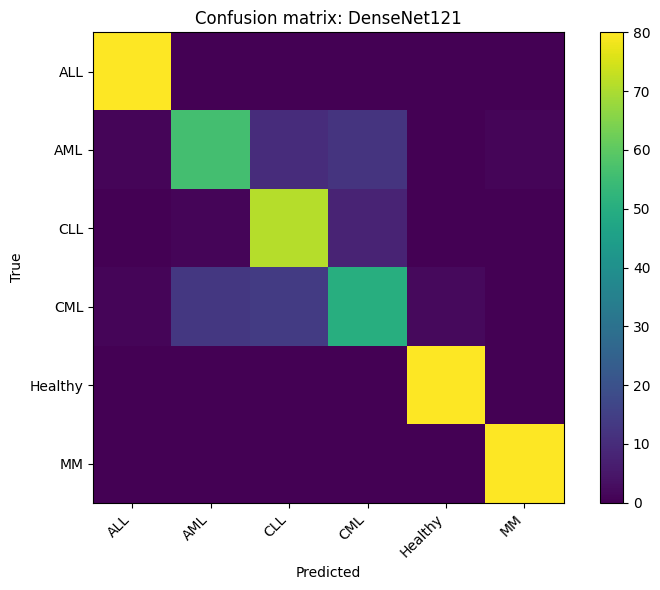


Model: EfficientNetB3
Test accuracy: 0.7417

Classification report:
              precision    recall  f1-score   support

         ALL     0.8605    0.9250    0.8916        80
         AML     0.5663    0.5875    0.5767        80
         CLL     0.7292    0.4375    0.5469        80
         CML     0.5060    0.5250    0.5153        80
     Healthy     0.8778    0.9875    0.9294        80
          MM     0.8778    0.9875    0.9294        80

    accuracy                         0.7417       480
   macro avg     0.7362    0.7417    0.7315       480
weighted avg     0.7362    0.7417    0.7315       480



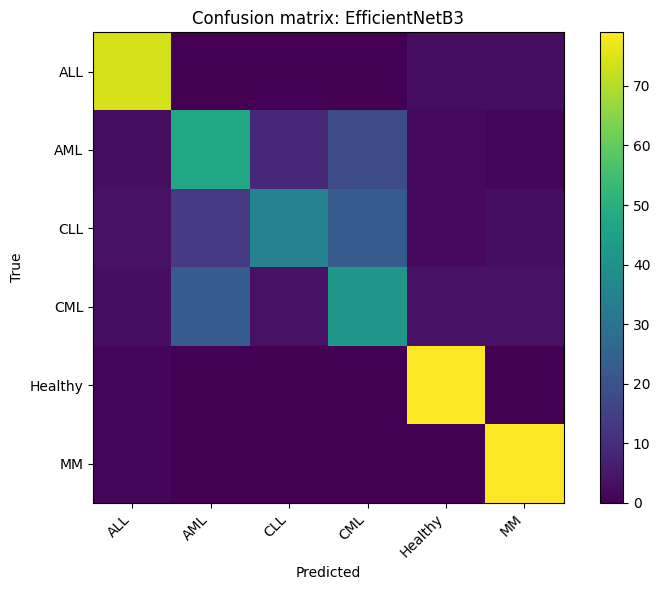


Accuracy ranking (test):
VGG16 -> 0.9062
DenseNet121 -> 0.8687
EfficientNetB3 -> 0.7417

Top 2 models: VGG16 and DenseNet121


In [11]:
# Compare Results and Pick Top 2 Models
acc_vgg = evaluate_and_report(vgg_model, "VGG16")
acc_dn = evaluate_and_report(densenet_model, "DenseNet121")
acc_en = evaluate_and_report(effnet_model, "EfficientNetB3")

results = {
    "VGG16": float(acc_vgg),
    "DenseNet121": float(acc_dn),
    "EfficientNetB3": float(acc_en),
}

sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
print("\nAccuracy ranking (test):")
for k, v in sorted_results:
    print(k, "->", round(v, 4))

print("\nTop 2 models:", sorted_results[0][0], "and", sorted_results[1][0])